In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#EDA 

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

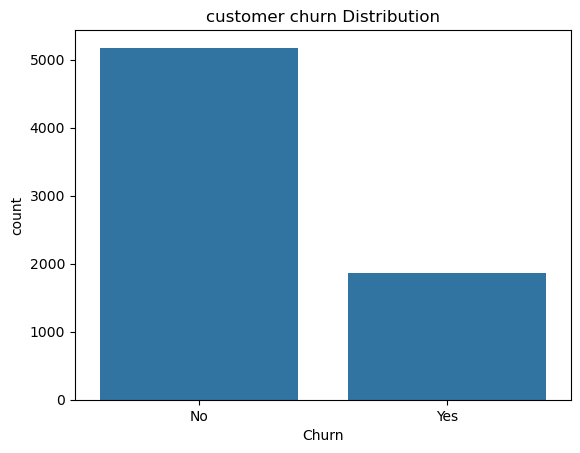

In [9]:
sns.countplot(x='Churn',data=df)
plt.title("customer churn Distribution")
plt.show()

In [10]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Preprocessing (Prepare the data for Machine Learning)

In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
df.drop('customerID',axis=1,inplace=True)

In [14]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [15]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [16]:
df['Churn'].head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: Churn, dtype: int64

Handle TotalCharges Column
Sometimes this column becomes object type.
usage:
Converts TotalCharges into numeric values.

In [17]:
df['totalcharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [18]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
totalcharges        11
dtype: int64

In [19]:
df.dropna(inplace=True)

In [20]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
totalcharges        0
dtype: int64

In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [22]:

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
totalcharges        0
dtype: int64

In [23]:

df['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [24]:
df.dtypes


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
totalcharges        float64
dtype: object

## Machine Learning Model Training *Train ML Model — Random Forest / XGBoost*

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
model = RandomForestClassifier(random_state=42)

*Convert Categories to Numbers*

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.head()


,SeniorCitizen,tenure,MonthlyCharges,Churn,totalcharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,29.85,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,1889.50,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,108.15,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,1840.75,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,151.65,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
# x = df.drop("Churn_Yes", axixs=1)
# y = df ["Churn_Yes"]

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [30]:
df.columns


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'totalcharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service',
       ...
       'TotalCharges_995.35', 'TotalCharges_996.45', 'TotalCharges_996.85',
       'TotalCharges_996.95', 'TotalCharges_997.65', 'TotalCharges_997.75',
       'TotalCharges_998.1', 'TotalCharges_999.45', 'TotalCharges_999.8',
       'TotalCharges_999.9'],
      dtype='object', length=6560)

In [31]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'totalcharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TotalCharges_100.25', 'TotalCharges_100.35', 'TotalCharges_100.4', 'TotalCharges_100.8', 'TotalCharges_100.9', 'TotalCharges_1001.2', 'TotalCharges_1001.5', 'TotalCharges_1003.05', 'TotalCharges_1004.35', 'TotalCharges_1004.5', 'To

all done(error) now the ml pipeline

In [32]:
#Splits data into training and testing datasets.*Train Test Split*

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
# feature scaling (scale numerical values for better ml performance )
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test=scaler. transform(X_test)

In [34]:
# import random forest (import random forest ml algorithm)
from sklearn.ensemble import RandomForestClassifier

In [35]:
#create model (random forest model )
model = RandomForestClassifier(random_state=42)

In [36]:
#train model using traning data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
#predict customer churn 
y_pred = model.predict(X_test)

In [38]:
#accurcay
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("accuracy:", accuracy)

accuracy: 0.7903340440653873


In [39]:
#confusion matrix 
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[949,  84],
       [211, 163]], dtype=int64)

In [40]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.66      0.44      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



# EXPLAINABLE AI (XAI) — *Explainable AI (SHAP) 🚀*

In [41]:
import shap
import numpy as np

SHAP Explainable AI section.

In [42]:
explainer = shap.TreeExplainer(model) 

In [46]:
shap_values = explainer.shap_values(X_sample, check_additivity=False)




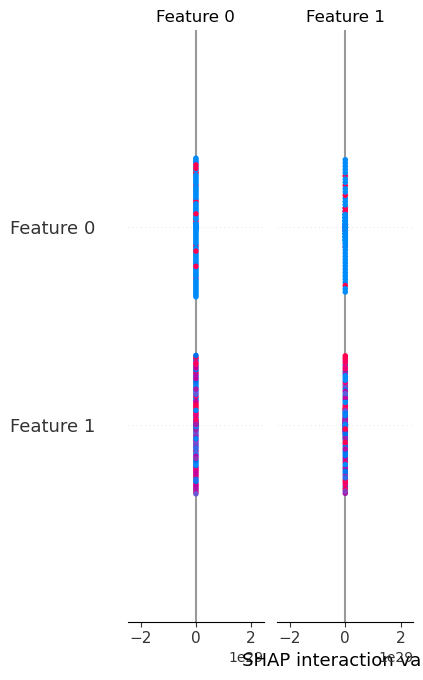

In [47]:
shap.summary_plot(shap_values, X_sample)

In [48]:
#Feature Importance Explanation

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,totalcharges,0.101096
1,tenure,0.094993
2,MonthlyCharges,0.084894
10,InternetService_Fiber optic,0.025089
28,PaymentMethod_Electronic check,0.023866
25,Contract_Two year,0.021979
13,OnlineSecurity_Yes,0.020921
19,TechSupport_Yes,0.019432
24,Contract_One year,0.018587
26,PaperlessBilling_Yes,0.017259


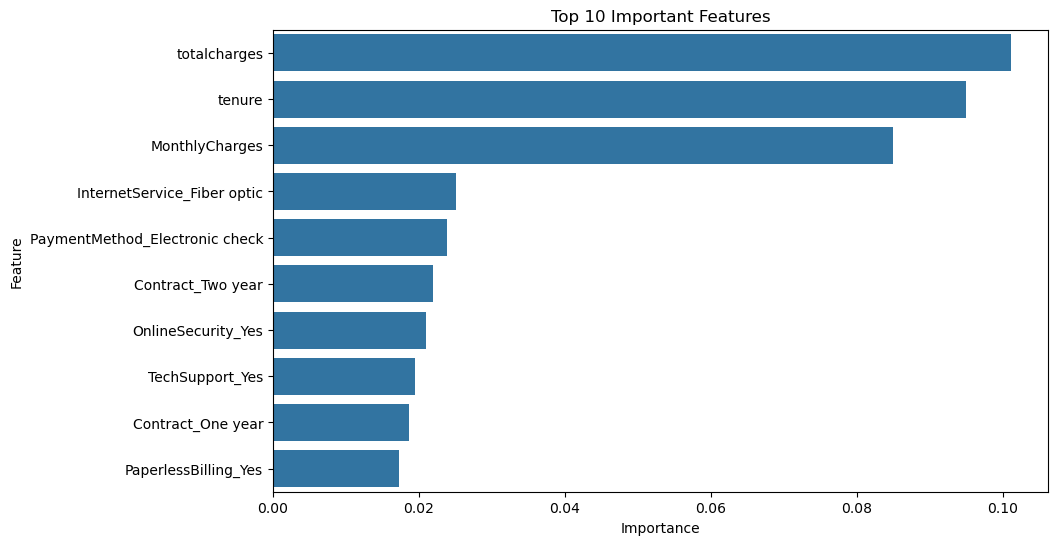

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


#feature_importances_ → Shows which features most influence customer churn prediction.

# BUSINESS INSIGHTS + AI RECOMMENDATIONS

In [52]:
print("BUSINESS INSIGHTS")
print("-" * 50)

print("1. Customers with high monthly charges are more likely to churn.")

print("2. Long-term contract customers have lower churn rates.")

print("3. Customers using fiber optic internet show higher churn.")

print("4. Senior citizens have slightly higher churn probability.")

print("5. Customers with shorter tenure are more likely to leave.")

BUSINESS INSIGHTS
--------------------------------------------------
1. Customers with high monthly charges are more likely to churn.
2. Long-term contract customers have lower churn rates.
3. Customers using fiber optic internet show higher churn.
4. Senior citizens have slightly higher churn probability.
5. Customers with shorter tenure are more likely to leave.


In [53]:
print("AI RECOMMENDATIONS")
print("-" * 50)

print("1. Offer discounts to high monthly charge customers.")

print("2. Encourage long-term contracts with special benefits.")

print("3. Improve customer service for fiber optic users.")

print("4. Create retention plans for new customers.")

print("5. Provide personalized offers using AI predictions.")

AI RECOMMENDATIONS
--------------------------------------------------
1. Offer discounts to high monthly charge customers.
2. Encourage long-term contracts with special benefits.
3. Improve customer service for fiber optic users.
4. Create retention plans for new customers.
5. Provide personalized offers using AI predictions.


# MODEL SAVING

In [54]:
import joblib

joblib.dump(model, "../models/churn_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
